# Temporal Identification 

**의존성**: 아래를 먼저 실행/보유하고 있어야 합니다.
- `CP_DIR / f"{source}_cp_metrics_t{threshold}_symnorm.csv"` (01번 산출물) — C, R, S, H
- `EMB_DIR / f"{source}_embeddings.pt"`, `EMB_DIR / f"{source}_temporal_attn.pt"` (`embedding_pipeline.ipynb` 산출물) — drift, attention

In [1]:
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import ruptures as rpt   # pip install ruptures --break-system-packages

# ── Paths ──────────────────────────────────────────────────
# BASE_DIR = 이 노트북이 있는 폴더. results/cp/ embeddings/ networks_emb/ 가
# 전부 이 밑에 형제 폴더로 있다고 가정합니다. 다른 곳이면 여기만 바꾸세요.
BASE_DIR = Path("..")   # notebooks/ 에서 실행 → 저장소 루트
CP_DIR       = BASE_DIR  / "results" / "cp"
EMB_DIR      = BASE_DIR / "data" / "processed" / "embeddings"
NETWORKS_DIR = BASE_DIR / "data" / "processed" / "networks_emb"

TI_DIR = BASE_DIR  / "results" / "cp" / "temporal_identification"
TI_DIR.mkdir(parents=True, exist_ok=True)

YEAR_START, YEAR_END = 1990, 2023
YEARS   = list(range(YEAR_START, YEAR_END + 1))
T       = len(YEARS)
SOURCES = ['news', 'paper']

EDGE_THRESHOLDS = {'news': 0.0, 'paper': 0.5}   # cp_pipeline과 동일해야 파일명이 맞음

INDICATOR_COLS = ['C', 'R', 'S', 'H', 'D', 'M']
print('Setup OK —', TI_DIR)

Setup OK — ../results/cp/temporal_identification


## Preparing indicator series

연도 x domain별 6차원 상태벡터 $(C_t, R_t, S_t, H_t, D_t, M_t)$를 만듭니다.
$C,R,S,H$는 `cp_pipeline.ipynb`가 이미 계산해둔 CSV에서 가져오고, $D$(drift)와
$M$(temporal-attention effective memory length)은 여기서 새로 계산합니다.
mean-lag·entropy도 같이 계산해서 $M$의 대안/강건성 지표로 남겨둡니다

In [2]:
def attention_summaries_per_node(A_node):
    """
    A_node: [T, T] causal attention for one node (row t sums to 1 over cols 0..t).
    Returns per-year mean_lag / entropy / effective_memory (perplexity 2**entropy).
    """
    T_ = A_node.shape[0]
    mean_lag = np.full(T_, np.nan)
    entropy  = np.full(T_, np.nan)
    eff_mem  = np.full(T_, np.nan)

    for t in range(T_):
        row = A_node[t, :t+1]
        s = row.sum()
        if s <= 0 or not np.isfinite(s):
            continue
        p = row / s
        lags = np.arange(t, -1, -1)
        mean_lag[t] = float((lags * p).sum())
        p_safe = p[p > 0]
        H = float(-(p_safe * np.log2(p_safe)).sum())
        entropy[t] = H
        eff_mem[t] = float(2 ** H)   # effective number of years attended to

    return {"mean_lag": mean_lag, "entropy": entropy, "effective_memory": eff_mem}


def domain_attention_series(source, agg="median"):
    """
    Loads {source}_temporal_attn.pt ([N,T,T]) and {source} active_mask (via cooc degree),
    returns a per-year DataFrame of median mean_lag / entropy / effective_memory
    across active nodes — same aggregation convention (median across active nodes)
    already used for drift/PageRank elsewhere in the pipeline.
    """
    attn = torch.load(EMB_DIR / f'{source}_temporal_attn.pt', map_location='cpu').numpy()  # [N,T,T]
    N = attn.shape[0]

    # active mask from co-occurrence degree (same source used by cooc_degree in embedding_pipeline)
    import scipy.sparse as sp
    active = np.zeros((T, N), dtype=bool)
    for t, yr in enumerate(YEARS):
        adj = sp.load_npz(NETWORKS_DIR / f'{source}_{yr}_adj_f.npz')
        active[t] = np.asarray(adj.sum(axis=1)).ravel() > 0

    per_node = {"mean_lag": np.full((N, T), np.nan),
                "entropy": np.full((N, T), np.nan),
                "effective_memory": np.full((N, T), np.nan)}
    for n in range(N):
        s = attention_summaries_per_node(attn[n])
        for k in per_node:
            per_node[k][n] = s[k]

    out = {}
    agg_fn = np.nanmedian if agg == "median" else np.nanmean
    for k, arr in per_node.items():
        arr = np.where(active.T, arr, np.nan)   # active is [T,N] -> [N,T]
        with np.errstate(all="ignore"):
            out[k] = agg_fn(arr, axis=0)
    return pd.DataFrame(out, index=YEARS)


attn_series = {src: domain_attention_series(src) for src in SOURCES}
for src in SOURCES:
    attn_series[src].to_csv(TI_DIR / f'{src}_attention_summary.csv')
print({src: attn_series[src].shape for src in SOURCES})

{'news': (34, 3), 'paper': (34, 3)}


In [3]:
def domain_drift_series(source, min_active_degree=2):
    """
    Domain-level D_t: median L2 drift among nodes active in both t-1 and t
    (same active-node convention used in the case-study drift plots).
    """
    emb = torch.load(EMB_DIR / f'{source}_embeddings.pt', map_location='cpu')
    emb = torch.nn.functional.normalize(emb, p=2, dim=-1)   # [T, N, D]
    drift = (emb[1:] - emb[:-1]).norm(dim=-1).numpy()        # [T-1, N]

    import scipy.sparse as sp
    N = emb.shape[1]
    deg = np.zeros((T, N), dtype=np.float32)
    for t, yr in enumerate(YEARS):
        adj = sp.load_npz(NETWORKS_DIR / f'{source}_{yr}_adj_f.npz')
        deg[t] = np.asarray(adj.sum(axis=1)).ravel()

    valid = (deg[:-1] >= min_active_degree) & (deg[1:] >= min_active_degree)   # [T-1, N]
    d_masked = np.where(valid, drift, np.nan)

    out = np.full(T, np.nan)
    out[1:] = np.nanmedian(d_masked, axis=1)
    return pd.Series(out, index=YEARS, name='D')


drift_series = {src: domain_drift_series(src) for src in SOURCES}
for src in SOURCES:
    drift_series[src].to_csv(TI_DIR / f'{src}_drift_summary.csv')
print({src: drift_series[src].dropna().shape for src in SOURCES})

{'news': (33,), 'paper': (33,)}


In [4]:
def load_cp_metrics(source):
    thr = EDGE_THRESHOLDS[source]
    df = pd.read_csv(CP_DIR / f"{source}_cp_metrics_t{thr}_symnorm.csv")
    return df


def assemble_state_vector(source):
    cp = load_cp_metrics(source).set_index('year')
    df = cp[['cit_mean', 'rit_mean', 'sit_mean', 'herfindahl_mean']].copy()
    df.columns = ['C', 'R', 'S', 'H']
    df['D'] = drift_series[source]
    df['M'] = attn_series[source]['effective_memory']
    df = df.reindex(YEARS)[INDICATOR_COLS]
    return df


state = {src: assemble_state_vector(src) for src in SOURCES}
for src in SOURCES:
    state[src].to_csv(TI_DIR / f'{src}_state_vector.csv')
    print(f"\n{src} state vector:")
    print(state[src].head())


news state vector:
             C         R      S         H         D         M
year                                                         
1990       NaN  0.622049  354.4  0.065887       NaN  1.000000
1991  0.508754  0.650836  303.5  0.031965  0.025611  1.928904
1992  0.651270  0.611194  350.8  0.058497  0.015720  2.184916
1993  0.527559  0.620196  392.2  0.063349  0.016933  3.202664
1994  0.532374  0.601509  379.2  0.078859  0.018446  3.797720

paper state vector:
             C         R       S         H         D         M
year                                                          
1990       NaN  0.386321  1213.0  0.065206       NaN  1.000000
1991  0.573949  0.393769  1198.0  0.073441  0.058515  1.979810
1992  0.560475  0.385962  1259.4  0.070297  0.048426  2.931595
1993  0.567251  0.391736  1242.0  0.086378  0.046493  3.883870
1994  0.559489  0.392884  1250.7  0.087192  0.045269  4.871723


In [5]:
def zscore_and_pc1(state_df, method="full_sample"):
    """
    state_df: [T,6] DataFrame, one domain. method='full_sample' (baseline) or
    'expanding' (robustness: no look-ahead in standardization).
    Returns (z_df, pc1_series, loadings). PC1 is oriented so higher = LESS
    stable (positive loading on churn C).
    """
    df = state_df.copy()
    if method == "full_sample":
        std = df.std(ddof=0)
        flat = std[std < 1e-10].index.tolist()
        if flat:
            print(f"[warn] near-zero-variance column(s) {flat} — z-score will be NaN/inf there.")
        z = (df - df.mean()) / std.replace(0, np.nan)
    elif method == "expanding":
        mu = df.expanding(min_periods=3).mean()
        sd = df.expanding(min_periods=3).std(ddof=0)
        z = (df - mu) / sd
    else:
        raise ValueError(method)

    z_clean = z.dropna()
    if z_clean.empty:
        raise ValueError(
            "zscore_and_pc1: z_clean is empty after dropna() -- every year has "
            "at least one NaN indicator.\n"
            f"Per-column NaN counts:\n{z.isna().sum()}\n"
            "Check the flagged column(s) above (a fully-NaN column, not just the "
            "expected single NaN in 'D' at the first year, means an upstream loader "
            "(cp_metrics / drift / attention) produced bad data for that source)."
        )
    X = z_clean.values - z_clean.values.mean(axis=0)
    U, S, Vt = np.linalg.svd(X, full_matrices=False)
    loadings = pd.Series(Vt[0], index=z_clean.columns)
    if loadings['C'] < 0:
        loadings = -loadings
    pc1 = pd.Series(np.nan, index=z.index)
    pc1.loc[z_clean.index] = X @ loadings.values / (np.linalg.norm(loadings.values) + 1e-12)
    return z, pc1, loadings


z_state, pc1, loadings = {}, {}, {}
for src in SOURCES:
    z_state[src], pc1[src], loadings[src] = zscore_and_pc1(state[src])
    z_state[src].to_csv(TI_DIR / f'{src}_state_vector_z.csv')
    pc1[src].to_csv(TI_DIR / f'{src}_structural_instability_index.csv')
    print(f"\n{src} PC1 loadings:\n{loadings[src]}")

# robustness variant (expanding-window standardization, no look-ahead)
z_state_expanding = {src: zscore_and_pc1(state[src], method="expanding")[0] for src in SOURCES}


news PC1 loadings:
C    0.362578
R    0.446235
S   -0.458305
H   -0.470116
D   -0.218858
M   -0.436418
dtype: float64

paper PC1 loadings:
C    0.435938
R   -0.393947
S   -0.436628
H   -0.423052
D    0.302322
M   -0.440168
dtype: float64


## Data-derived breakpoints — three-layer validation

1. **존재 검정 (CUSUM/sup-Wald)** — "이 시리즈에 breakpoint가 아예 있기는 한가"를 위치 추정 *전에* 먼저 검정. 통과 못 하면 그 domain은 여기서 멈춤.
2. **위치 추정 (PELT + BOCPD)** — 서로 다른 두 추론 패러다임(빈도주의 최적화 vs 베이지안 순차추론)으로 독립적으로 위치를 추정. 둘이 겹치면 더 강한 증거.
3. **안정성 (moving-block bootstrap + null 보정)** — 이미 있던 부분, PELT 후보의 신뢰도.

In [6]:
def cusum_existence_test(z_df, min_segment=3, n_boot=1000, block_len=4, seed=0):
    """
    Layer 1 -- multivariate sup-Wald/CUSUM: does at least one break exist
    ANYWHERE, tested before attempting to locate it (avoids the "find
    candidates, then ask if real" circularity).

    Uses identity-weighted (plain L2) squared distance between segment
    means, NOT a full 6x6 inverse-covariance (Mahalanobis) weighting --
    with T~34 and 6 dimensions, estimating a full covariance matrix is too
    unstable and destroys power (empirically confirmed: Mahalanobis gave
    p=0.096 on a clear synthetic break; identity-weighted gave p=0.040 on
    the same data, with the null scenario staying correctly non-significant
    at p=0.38). This matches the "l2" cost already used in PELT.
    """
    z_clean = z_df.dropna()
    X = z_clean.values
    years_ = z_clean.index.to_numpy()
    T, dim = X.shape

    def sup_stat(Xa):
        n = len(Xa)
        best, best_k = -np.inf, None
        for k in range(min_segment, n - min_segment + 1):
            diff = Xa[:k].mean(0) - Xa[k:].mean(0)
            stat = (k * (n - k) / n) * (diff @ diff)
            if stat > best:
                best, best_k = stat, k
        return best, best_k

    obs_stat, obs_k = sup_stat(X)
    obs_year = int(years_[obs_k - 1]) if obs_k else None

    rng = np.random.default_rng(seed)
    null_stats = []
    for _ in range(n_boot):
        idx = []
        while len(idx) < T:
            start = rng.integers(0, max(T - block_len, 1))
            idx.extend(range(start, min(start + block_len, T)))
        idx = np.array(idx[:T])
        s, _ = sup_stat(X[idx])
        null_stats.append(s)
    null_stats = np.array(null_stats)
    p_value = float((null_stats >= obs_stat).mean())
    return {"sup_statistic": obs_stat, "candidate_year": obs_year,
            "p_value": p_value, "exists": bool(p_value < 0.05),
            "null_distribution": null_stats}


cusum_results = {}
for src in SOURCES:
    cusum_results[src] = cusum_existence_test(z_state[src])
    r = cusum_results[src]
    print(f"{src}: sup_stat={r['sup_statistic']:.2f}  strongest candidate={r['candidate_year']}  "
          f"p={r['p_value']:.4f}  exists={r['exists']}")

pd.DataFrame({src: {"p_value": cusum_results[src]["p_value"],
                     "exists": cusum_results[src]["exists"],
                     "candidate_year": cusum_results[src]["candidate_year"]}
              for src in SOURCES}).T.to_csv(TI_DIR / "cusum_existence_test.csv")

if not any(cusum_results[src]["exists"] for src in SOURCES):
    print("\n[NOTE] Neither domain passed the existence test at p<0.05. "
          "Location estimation (PELT/BOCPD) below is still run for transparency/"
          "robustness reporting, but should NOT be presented as a confirmed break "
          "for a domain where exists=False -- report it as 'no evidence of a "
          "structural break' for that domain.")

news: sup_stat=101.71  strongest candidate=1998  p=0.0140  exists=True
paper: sup_stat=121.01  strongest candidate=2004  p=0.0080  exists=True


In [7]:
def detect_breakpoints(z_df, penalty="bic", min_size=3):
    z_clean = z_df.dropna()
    X = z_clean.values
    n, dim = X.shape
    pen = dim * np.log(n) if penalty == "bic" else float(penalty)
    algo = rpt.Pelt(model="l2", min_size=min_size, jump=1).fit(X)
    bkps = algo.predict(pen=pen)[:-1]
    years_ = z_clean.index.to_numpy()
    return [int(years_[b]) for b in bkps if 0 <= b < n]


def block_bootstrap_breakpoints(z_df, n_boot=500, block_len=4, penalty="bic",
                                 min_size=3, tol_years=2, seed=0):
    rng = np.random.default_rng(seed)
    z_clean = z_df.dropna()
    X = z_clean.values
    years_ = z_clean.index.to_numpy()
    n, dim = X.shape

    observed = detect_breakpoints(z_df, penalty=penalty, min_size=min_size)
    boot_hits = {yr: 0 for yr in observed}
    boot_locations = {yr: [] for yr in observed}
    pen = dim * np.log(n) if penalty == "bic" else float(penalty)

    for _ in range(n_boot):
        idx = []
        while len(idx) < n:
            start = rng.integers(0, max(n - block_len, 1))
            idx.extend(range(start, min(start + block_len, n)))
        idx = np.array(idx[:n])
        Xb = X[idx]
        try:
            algo = rpt.Pelt(model="l2", min_size=min_size, jump=1).fit(Xb)
            bkps_b = algo.predict(pen=pen)[:-1]
        except Exception:
            bkps_b = []
        boot_years_b = [years_[min(b, n - 1)] for b in bkps_b]
        for yr in observed:
            hit = [by for by in boot_years_b if abs(yr - by) <= tol_years]
            if hit:
                boot_hits[yr] += 1
                boot_locations[yr].extend(hit)

    rows = []
    for yr in observed:
        freq = boot_hits[yr] / n_boot
        locs = boot_locations[yr]
        ci = (int(np.percentile(locs, 2.5)), int(np.percentile(locs, 97.5))) if locs else (None, None)
        rows.append({"breakpoint_year": yr, "detection_freq": freq, "ci_95": ci})
    return pd.DataFrame(rows)


def null_calibrated_threshold(z_df, n_null=100, percentile=95, n_boot=100, min_size=3, seed=1):
    """
    Data-driven alternative to a fixed FREQ_THRESHOLD guess.

    Shuffles the *year order* of the standardized indicator series (destroys
    any real change-point structure while keeping each year's own 6-dim
    vector intact, so marginal distributions/correlations across indicators
    are preserved), reruns detect_breakpoints + block_bootstrap_breakpoints
    on each shuffle, and takes the `percentile`-th percentile of the
    *maximum* detection_freq seen across shuffles.

    This answers: "how high can detection_freq get by chance alone, on a
    series with no real structure?" -- and uses that as the bar, instead of
    an arbitrary fixed number decided before seeing what the noise floor
    for THIS series length/bootstrap design actually looks like.
    """
    rng = np.random.default_rng(seed)
    z_clean = z_df.dropna()
    idx = z_clean.index.to_numpy()
    max_freqs = []
    for _ in range(n_null):
        perm = rng.permutation(len(idx))
        z_perm = pd.DataFrame(z_clean.values[perm], index=idx, columns=z_clean.columns)
        bkps = detect_breakpoints(z_perm, min_size=min_size)
        if not bkps:
            max_freqs.append(0.0)
            continue
        boot = block_bootstrap_breakpoints(z_perm, n_boot=n_boot, min_size=min_size)
        max_freqs.append(float(boot['detection_freq'].max()) if not boot.empty else 0.0)
    return float(np.percentile(max_freqs, percentile)), np.array(max_freqs)


breakpoints_raw, breakpoints_boot, freq_thresholds, null_dists = {}, {}, {}, {}
for src in SOURCES:
    breakpoints_raw[src]  = detect_breakpoints(z_state[src])
    breakpoints_boot[src] = block_bootstrap_breakpoints(z_state[src])
    breakpoints_boot[src].to_csv(TI_DIR / f'{src}_breakpoints_bootstrap.csv', index=False)

    freq_thresholds[src], null_dists[src] = null_calibrated_threshold(z_state[src])
    print(f"\n{src} candidate breakpoints:\n{breakpoints_boot[src]}")
    print(f"{src} null-calibrated FREQ_THRESHOLD (95th pct of shuffled max freq): {freq_thresholds[src]:.3f}")

pd.DataFrame({src: null_dists[src] for src in SOURCES}).to_csv(TI_DIR / 'freq_threshold_null_distribution.csv', index=False)

retained_breakpoints = {
    src: breakpoints_boot[src].loc[breakpoints_boot[src]['detection_freq'] >= freq_thresholds[src], 'breakpoint_year'].tolist()
    for src in SOURCES
}
print("\nRetained (>= domain-specific null-calibrated threshold):", retained_breakpoints)
print("(fixed FREQ_THRESHOLD=0.70 is no longer used -- kept below only for reference/reporting)")
FREQ_THRESHOLD = {src: freq_thresholds[src] for src in SOURCES}   # for the record / manuscript reporting


news candidate breakpoints:
   breakpoint_year  detection_freq         ci_95
0             1998           0.274  (1997, 1999)
1             2017           0.406  (2015, 2019)
news null-calibrated FREQ_THRESHOLD (95th pct of shuffled max freq): 0.180

paper candidate breakpoints:
   breakpoint_year  detection_freq         ci_95
0             2002           0.282  (2002, 2003)
1             2013           0.528  (2011, 2015)
paper null-calibrated FREQ_THRESHOLD (95th pct of shuffled max freq): 0.220

Retained (>= domain-specific null-calibrated threshold): {'news': [1998, 2017], 'paper': [2002, 2013]}
(fixed FREQ_THRESHOLD=0.70 is no longer used -- kept below only for reference/reporting)


In [8]:
def bocpd_location(z_df, lam=25, k_prior=5.0, min_size=3):
    """
    Layer 2b -- independent (Bayesian sequential) cross-check on breakpoint
    LOCATION, using genuinely multivariate BOCPD (NormalInvWishart prior).
    A different inferential paradigm from PELT's frequentist optimization
    (layer 2a, already implemented above), so agreement between the two is
    stronger triangulating evidence than either alone.

    lam=25, k_prior=5.0 chosen after checking both a synthetic true-break
    scenario (correctly found candidates near the injected year) and a pure
    null scenario (correctly found ZERO candidates) -- weaker settings
    (shorter lam, weaker prior) were oversensitive and fired on pure noise.
    """
    import changepoint as cpt
    z_clean = z_df.dropna()
    X = z_clean.values
    years_ = z_clean.index.to_numpy()
    T, dim = X.shape
    prior = cpt.NormalInvWishart(mu=X.mean(0).tolist(), k=k_prior, df=dim + 2,
                                  scale=np.cov(X.T).tolist())
    cpd = cpt.Bocpd(prior=prior, lam=lam)
    history = np.zeros((T, T))
    for i, x in enumerate(X):
        r = cpd.step(x.tolist())
        history[i, :len(r)] = r
    cps_idx = cpt.map_changepoints(history)
    cps_idx = [c for c in cps_idx if min_size <= c <= T - min_size]
    return [int(years_[c]) for c in cps_idx]


bocpd_candidates = {src: bocpd_location(z_state[src]) for src in SOURCES}
for src in SOURCES:
    pelt_set  = set(breakpoints_raw[src])
    bocpd_set = set(bocpd_candidates[src])
    overlap = {y for py in pelt_set for y in bocpd_set if abs(py - y) <= 2}
    print(f"\n{src}:")
    print(f"  PELT candidates : {sorted(pelt_set)}")
    print(f"  BOCPD candidates: {sorted(bocpd_set)}")
    print(f"  Within +-2y of both (cross-paradigm agreement): {sorted(overlap) if overlap else 'none'}")

pd.DataFrame([{"source": s, "pelt": breakpoints_raw[s], "bocpd": bocpd_candidates[s]} for s in SOURCES]) \
    .to_csv(TI_DIR / "pelt_vs_bocpd.csv", index=False)


news:
  PELT candidates : [1998, 2017]
  BOCPD candidates: [1997, 1998, 2006, 2016, 2020]
  Within +-2y of both (cross-paradigm agreement): [1997, 1998, 2016]

paper:
  PELT candidates : [2002, 2013]
  BOCPD candidates: [1998, 2001, 2002, 2004, 2014, 2016]
  Within +-2y of both (cross-paradigm agreement): [2001, 2002, 2004, 2014]


## Cross-arena ordering

paper/news의 구조적 불안정성 지수(PC1)로 cross-correlation function(CCF)을 구하고,
block-bootstrap null로 peak lag의 유의성을 봅니다. 이미 코드에 있는 Cox
time-varying lag 분석(개념 단위)과는 다른, 집계 단위의 독립적 증거입니다.

In [9]:
def cross_correlation(x, y, max_lag=5):
    # NOTE: drop NaN *before* intersecting — pc1 is always NaN at the very
    # first year (drift/D is undefined with no prior-year embedding to diff
    # against), and a single NaN silently poisons plain .mean()/.std() into
    # NaN for the whole array, which was making every lag's correlation NaN.
    x_valid = x.dropna()
    y_valid = y.dropna()
    common = x_valid.index.intersection(y_valid.index)
    if len(common) < 2 * max_lag + 3:
        print(f"[warn] cross_correlation: only {len(common)} valid overlapping years "
              f"after dropping NaN — results may be unreliable or all-NaN.")
    xs, ys = x_valid.loc[common].values, y_valid.loc[common].values
    xs = (xs - xs.mean()) / (xs.std() + 1e-12)
    ys = (ys - ys.mean()) / (ys.std() + 1e-12)
    n = len(xs)
    lags = range(-max_lag, max_lag + 1)
    out = []
    for k in lags:
        if k >= 0:
            a, b = xs[k:], (ys[:n-k] if k > 0 else ys)
        else:
            a, b = xs[:n+k], ys[-k:]
        out.append(np.nan if len(a) < 3 else float(np.corrcoef(a, b)[0, 1]))
    return pd.Series(out, index=list(lags))


def ccf_block_bootstrap_null(x, y, max_lag=5, n_boot=1000, block_len=4, seed=0):
    rng = np.random.default_rng(seed)
    common = x.index.intersection(y.index)
    n = len(common)
    y_vals = y.loc[common].values
    peak_null = []
    for _ in range(n_boot):
        idx = []
        while len(idx) < n:
            start = rng.integers(0, max(n - block_len, 1))
            idx.extend(range(start, min(start + block_len, n)))
        idx = np.array(idx[:n])
        y_shuf = pd.Series(y_vals[idx], index=common)
        ccf_b = cross_correlation(x.loc[common], y_shuf, max_lag=max_lag)
        peak_null.append(np.nanmax(np.abs(ccf_b.values)))
    return np.array(peak_null)


ccf_obs = cross_correlation(pc1['paper'], pc1['news'], max_lag=5)
ccf_null = ccf_block_bootstrap_null(pc1['paper'], pc1['news'], max_lag=5)
peak_lag = int(ccf_obs.abs().idxmax())
peak_r   = float(ccf_obs.loc[peak_lag])
p_value  = float((ccf_null >= abs(peak_r)).mean())

print(ccf_obs)
print(f"\nPeak lag = {peak_lag} years (positive = paper leads), r = {peak_r:.3f}, bootstrap p = {p_value:.4f}")

ccf_obs.to_csv(TI_DIR / 'ccf_paper_vs_news.csv')
pd.Series(ccf_null).to_csv(TI_DIR / 'ccf_bootstrap_null.csv', index=False)

-5    0.891600
-4    0.899559
-3    0.909313
-2    0.917758
-1    0.926478
 0    0.934547
 1    0.924398
 2    0.921636
 3    0.927868
 4    0.920362
 5    0.917152
dtype: float64

Peak lag = 0 years (positive = paper leads), r = 0.935, bootstrap p = 0.0000


In [10]:
from scipy import stats as _st

trend_rows = []
for src in SOURCES:
    v = pc1[src].dropna()
    sl, ic, r, p, se = _st.linregress(v.index.values.astype(float), v.values)
    trend_rows.append({"source": src, "slope_per_year": sl, "r_vs_year": r, "p_trend": p})
trend_df = pd.DataFrame(trend_rows)
print("PC1 linear trend against calendar year:")
print(trend_df.to_string(index=False))

ccf_diff      = cross_correlation(pc1['paper'].diff(), pc1['news'].diff(), max_lag=5)
ccf_diff_null = ccf_block_bootstrap_null(pc1['paper'].diff(), pc1['news'].diff(), max_lag=5)
peak_lag_diff = int(ccf_diff.abs().idxmax())
peak_r_diff   = float(ccf_diff.loc[peak_lag_diff])
p_diff        = float((ccf_diff_null >= abs(peak_r_diff)).mean())

cmp_df = pd.DataFrame({"ccf_levels": ccf_obs.round(4), "ccf_first_diff": ccf_diff.round(4)})
cmp_df.index.name = "lag"
cmp_df.to_csv(TI_DIR / 'ccf_levels_vs_firstdiff.csv')
print("\nCCF, levels vs first differences (positive lag = paper leads):")
print(cmp_df.to_string())

flat_levels = float(ccf_obs.abs().max() - ccf_obs.abs().min())
flat_diff   = float(ccf_diff.abs().max() - ccf_diff.abs().min())
print(f"\n  levels     : peak lag = {peak_lag:+d}, r = {peak_r:.3f}, bootstrap p = {p_value:.4f}, "
      f"spread of |r| across lags = {flat_levels:.3f}")
print(f"  first-diff : peak lag = {peak_lag_diff:+d}, r = {peak_r_diff:.3f}, bootstrap p = {p_diff:.4f}, "
      f"spread of |r| across lags = {flat_diff:.3f}")

CCF_ORDERING_IDENTIFIED = bool(p_diff < 0.05)
print(f"\nCCF_ORDERING_IDENTIFIED = {CCF_ORDERING_IDENTIFIED}")

PC1 linear trend against calendar year:
source  slope_per_year  r_vs_year      p_trend
  news       -0.198110  -0.932468 2.973497e-15
 paper       -0.226988  -0.990542 2.602002e-28

CCF, levels vs first differences (positive lag = paper leads):
     ccf_levels  ccf_first_diff
lag                            
-5       0.8916          0.1422
-4       0.8996         -0.0895
-3       0.9093          0.0436
-2       0.9178         -0.0203
-1       0.9265         -0.0037
 0       0.9345          0.1152
 1       0.9244         -0.1202
 2       0.9216         -0.2032
 3       0.9279          0.2333
 4       0.9204         -0.0424
 5       0.9172         -0.0734

  levels     : peak lag = +0, r = 0.935, bootstrap p = 0.0000, spread of |r| across lags = 0.043
  first-diff : peak lag = +3, r = 0.233, bootstrap p = 0.8620, spread of |r| across lags = 0.230

CCF_ORDERING_IDENTIFIED = False


## Persistence

break 시점 전후 window년 구간의 평균 벡터가 실제로 다른지 permutation test로
검정합니다. 통과 못 하면 "break"가 아니라 일시적 진동으로 처리하고 분류에서
제외합니다.

In [11]:
from itertools import combinations
from math import comb


def _between_mean_stat(a, b):
    """
    Identity-weighted (plain L2) between-segment statistic, scaled exactly
    like the sup-Wald statistic in cusum_existence_test:
        n_a n_b / (n_a + n_b) * || mean(a) - mean(b) ||^2
    """
    na, nb = len(a), len(b)
    d = a.mean(0) - b.mean(0)
    return float(na * nb / (na + nb) * (d @ d))


def _perm_p(X, pre_mask, post_mask, n_perm=2000, seed=0, exact_limit=20000):
    """
    Permutation p-value for a pre/post labelling. Enumerates ALL labellings
    when the space is small (it always is here: C(10,5) = 252), otherwise
    falls back to random permutations with the standard (1+#ge)/(1+B)
    estimator. Returns (obs, p, n_used, exact_flag).
    """
    obs = _between_mean_stat(X[pre_mask], X[post_mask])
    idx = np.where(pre_mask | post_mask)[0]
    n_pre, n = int(pre_mask.sum()), len(idx)
    n_splits = comb(n, n_pre)
    if n_splits <= exact_limit:
        pool = set(idx)
        null = np.array([_between_mean_stat(X[list(c)], X[sorted(pool - set(c))])
                         for c in combinations(idx, n_pre)])
        return obs, float((null >= obs - 1e-12).mean()), n_splits, True
    rng = np.random.default_rng(seed)
    null = []
    for _ in range(n_perm):
        pm = rng.permutation(idx)
        null.append(_between_mean_stat(X[pm[:n_pre]], X[pm[n_pre:]]))
    null = np.array(null)
    return obs, float((1 + (null >= obs - 1e-12).sum()) / (1 + n_perm)), n_perm, False


def persistence_test(z_df, break_year, window=5, n_perm=2000, seed=0, min_side=3):
    """
    Layer 4 -- is the shift at `break_year` a PERSISTENT regime change or a
    one-year excursion? Permutation test on pre-window vs post-window mean
    vectors.

    =====================================================================
    [FIXED -- two independent defects found the first time this notebook was
     run end-to-end on the real data. Both made the test VACUOUS rather than
     merely weak, and together they are the reason confirmed_breakpoints came
     out empty and pathways_df came out as an empty DataFrame.]

    (1) THE STATISTIC WAS MATHEMATICALLY CONSTANT.
        The old version used a pooled-covariance (Mahalanobis) distance
        between the pre- and post-window mean vectors:
            pooled = np.cov(vstack([a, b]).T) + 1e-6*I ;  d @ pinv(pooled) @ d
        With window=3 that is 3 vs 3 points in 6 dimensions -- i.e. 6 points
        in R^6. Six points in general position, whitened by their own pooled
        covariance, ARE the vertices of a regular 5-simplex. So the squared
        Mahalanobis distance between ANY 3-vs-3 split of them is identically
            (4/9) * 1.8 * |v|^2  =  10/3  =  3.3333...
        no matter what the data are. That constant is exactly what the old
        run printed as its "distance" column: 3.333325, 3.333306, 3.333322,
        3.333307 -- all 10/3 to five decimals, for four different breakpoints
        in two different domains. Observed and permuted values were the same
        constant, so the p-value was decided purely by float64 rounding.
        Proof: identical code, identical seed, two machines with different
        BLAS builds -> news=0.055/paper=0.111 on one and news=0.111/
        paper=0.055 on the other. The two domains simply swapped p-values.

        Fix: identity-weighted (plain L2) between-mean statistic. Same
        argument, same choice, already documented in cusum_existence_test
        above: with this few points a full 6x6 inverse covariance cannot be
        estimated and destroys the test. It applies with far more force to a
        3-vs-3 window than to the full T~34 series.

    (2) window=3 COULD NOT REACH p<0.05 EVEN IN PRINCIPLE.
        A 3-vs-3 exchangeability test has only C(6,3)/2 = 10 distinct
        labellings, so the smallest attainable p-value is 0.10. persists =
        (p < 0.05) was therefore guaranteed False for every candidate no
        matter how large the true shift. Default widened to window=5:
        C(10,5)/2 = 126 distinct labellings, smallest attainable p = 0.0079.
        `p_min` is now returned next to every p-value so this floor can
        never be invisible again, and window sensitivity is printed below.

    Also added: `*_excl_break` -- the same test with the break year itself
    dropped from the post-window. THAT is what actually discriminates a
    sustained regime shift from a single-year spike: a spike collapses once
    its own year is removed, a genuine shift does not. Validated in the
    self-test below (injected 2012 regime change passes both; injected
    1997/2016 one-year spikes pass neither).
    =====================================================================
    """
    z_clean = z_df.dropna()
    years_ = z_clean.index.to_numpy()
    X = z_clean.values

    pre_mask  = (years_ >= break_year - window) & (years_ < break_year)
    post_mask = (years_ >= break_year) & (years_ < break_year + window)
    n_pre, n_post = int(pre_mask.sum()), int(post_mask.sum())
    if n_pre < min_side or n_post < min_side:
        return {"distance": np.nan, "p_value": np.nan, "persists": False,
                "n_pre": n_pre, "n_post": n_post, "p_min": np.nan,
                "dist_excl_break": np.nan, "p_excl_break": np.nan,
                "persists_excl_break": False, "n_perm_used": 0,
                "exact_enumeration": False,
                "note": "insufficient years in pre/post window"}

    obs, p, n_used, exact = _perm_p(X, pre_mask, post_mask, n_perm=n_perm, seed=seed)
    n_splits = comb(n_pre + n_post, n_pre)
    p_min = (2.0 / n_splits if n_pre == n_post else 1.0 / n_splits) if exact else 1.0 / (1 + n_perm)

    # spike-robust variant: drop the break year itself from the post window
    post2 = (years_ > break_year) & (years_ <= break_year + window)
    if int(post2.sum()) >= min_side:
        obs2, p2, _, _ = _perm_p(X, pre_mask, post2, n_perm=n_perm, seed=seed)
    else:
        obs2, p2 = np.nan, np.nan

    return {"distance": obs, "p_value": p, "persists": bool(p < 0.05),
            "dist_excl_break": obs2, "p_excl_break": p2,
            "persists_excl_break": bool(p2 < 0.05) if np.isfinite(p2) else False,
            "n_pre": n_pre, "n_post": n_post, "p_min": p_min,
            "n_perm_used": n_used, "exact_enumeration": exact}


PERSISTENCE_WINDOW = 5

persistence_results = []
for src in SOURCES:
    for yr in retained_breakpoints[src]:
        res = persistence_test(z_state[src], yr, window=PERSISTENCE_WINDOW)
        res.update({"source": src, "break_year": yr})
        persistence_results.append(res)

persistence_df = pd.DataFrame(persistence_results)[
    ["source", "break_year", "n_pre", "n_post", "distance", "p_value", "p_min",
     "persists", "dist_excl_break", "p_excl_break", "persists_excl_break",
     "n_perm_used", "exact_enumeration"]]
persistence_df.to_csv(TI_DIR / 'persistence_tests.csv', index=False)
print(f"Persistence test (window={PERSISTENCE_WINDOW}, exact permutation enumeration):")
print(persistence_df.to_string(index=False))

# --- window sensitivity, including the old default (3) so the floor is explicit
sens = []
for w in [3, 4, 5, 6]:
    for src in SOURCES:
        for yr in retained_breakpoints[src]:
            r = persistence_test(z_state[src], yr, window=w)
            sens.append({"window": w, "source": src, "break_year": yr,
                         "distance": r["distance"], "p_value": r["p_value"],
                         "p_min": r["p_min"], "persists": r["persists"]})
sens_df = pd.DataFrame(sens)
sens_df.to_csv(TI_DIR / 'persistence_window_sensitivity.csv', index=False)
print("\nWindow sensitivity (p_min = smallest p-value attainable at that window):")
print(sens_df.pivot_table(index=["source", "break_year"], columns="window",
                          values=["p_value", "p_min", "distance"]).round(4).to_string())
print("\n[note] at window=3 every p_value sits exactly at p_min=0.10 -- the test is "
      "pinned to its own floor and cannot reject at 0.05 regardless of effect size. "
      "That, together with the constant-10/3 Mahalanobis statistic, is what emptied "
      "confirmed_breakpoints in the pre-fix run.")

confirmed_breakpoints = {
    src: [r["break_year"] for r in persistence_results
          if r["source"] == src and r.get("persists")]
    for src in SOURCES
}
confirmed_strict = {
    src: [r["break_year"] for r in persistence_results
          if r["source"] == src and r.get("persists") and r.get("persists_excl_break")]
    for src in SOURCES
}
print("\nConfirmed (persistent) breakpoints:", confirmed_breakpoints)
print("Confirmed AND spike-robust (break year itself excluded):", confirmed_strict)

Persistence test (window=5, exact permutation enumeration):
source  break_year  n_pre  n_post  distance  p_value    p_min  persists  dist_excl_break  p_excl_break  persists_excl_break  n_perm_used  exact_enumeration
  news        1998      5       5 27.797136 0.007937 0.007937      True        28.696152      0.007937                 True          252               True
  news        2017      5       5  9.718626 0.007937 0.007937      True        11.310280      0.007937                 True          252               True
 paper        2002      5       5  7.955790 0.007937 0.007937      True         9.810738      0.007937                 True          252               True
 paper        2013      5       5  5.889220 0.023810 0.007937      True         6.948686      0.015873                 True          252               True

Window sensitivity (p_min = smallest p-value attainable at that window):
                  distance                            p_min                         p_

## Regime vs. trend — 시기 구분이 실재하는지에 대한 직접 검정

§3.6의 목적은 "역사적 사건으로 시기를 정의하고 그 시기로 다시 사건을 확인하는"
순환을 끊고 데이터에서 bottom-up으로 시기를 뽑는 것입니다. 그런데 §3.6.2–3.6.4를
전부 통과했더라도 아직 답하지 않은 질문이 하나 남습니다:

> **애초에 "시기"라는 것이 이 데이터에 있기는 한가?**

changepoint 알고리즘은 **매끄러운 추세에도 언제나 breakpoint를 반환합니다** — 직선을
계단으로 근사하는 최적 지점을 내놓기 때문입니다. 따라서 "PELT가 2002년을 찾았다"는
"2002년에 체제가 바뀌었다"를 뜻하지 않습니다. 심사에서 나올 가장 날카로운 반박이
정확히 이것입니다.

§3.6.3b에서 두 PC1 시계열이 거의 결정론적 추세(연도 대비 |r| = 0.93 / 0.99)임이
드러났으므로, 이건 가정이 아니라 검정 대상입니다. 아래 네 가지로 검정합니다.

| | 검정 | 무엇을 가리는가 |
|---|---|---|
| A | BIC 모형 비교 (상수 / 직선 / 계단 / 직선+레벨이동) | 계단이 직선보다 나은가 |
| B | 선형 추세 제거 후 breakpoint 재검출 | 추세를 빼도 같은 해가 남는가 |
| C | 연도×연도 거리행렬: 블록 구조 vs 거리감쇠 | 경계가 뚜렷한가, 매끄럽게 멀어지는가 |
| D | **파라메트릭 부트스트랩 LR test** (위치 재탐색 포함) | 결정적 검정 |

D가 결정적인 이유: H0를 "추세만 있고 레벨 이동은 없다"로 두고, **부트스트랩 표본마다
이동 위치를 다시 탐색**하기 때문에 §3.6.2가 안고 있던 탐색 편의(가장 잘 맞는 연도를
고른 뒤 그 연도에서 검정하는 문제)까지 함께 보정됩니다.

> **추가 경고 — §3.6.2의 CUSUM 존재 검정도 추세에 오염돼 있습니다.**
> 아래 시뮬레이션이 보여주듯, break가 전혀 없는 순수 추세 시계열에서도 이 검정은
> 실제 데이터와 같은 추세 강도에서 **96.5% 확률로 p<0.05**를 냅니다(중앙값 p ≈ 0.015 —
> 관측된 news 0.014 / paper 0.008과 사실상 동일). 즉 `cusum_results`의 p-value는
> "break가 있다"가 아니라 **"추세가 있다"**를 검정한 값입니다. 순환을 끊으려고 맨 앞에
> 놓은 Layer 1이 정작 그 역할을 못 하고 있었던 셈이므로, §4.3에서 이 p-value를 break의
> 근거로 인용하면 안 됩니다. 추세 제거 후 값(news 0.261, paper 0.183)이 정직한 수치입니다.

In [12]:
# ── [ADDED] 3.6.5  Regime vs trend ────────────────────────────────────────────

def _bic(rss, N, k):
    return N * np.log(rss / N) + k * np.log(N)

def _fit_rss(X, t, brk_idx, n):
    """RSS of: intercept + slope*t + one level dummy per break (brk_idx empty => trend only)."""
    Dm = np.column_stack([np.ones(n), t] + [(np.arange(n) >= b).astype(float) for b in brk_idx])
    F = Dm @ np.linalg.lstsq(Dm, X, rcond=None)[0]
    return float(((X - F) ** 2).sum())

def _best_two_breaks(X, t, n, min_size=3):
    best = (np.inf, None)
    for a in range(min_size, n - 2 * min_size + 1):
        for b in range(a + min_size, n - min_size + 1):
            r = _fit_rss(X, t, [a, b], n)
            if r < best[0]:
                best = (r, (a, b))
    return best

# ---------- A. BIC model comparison ----------
rowsA = []
for src in SOURCES:
    zc = z_state[src].dropna(); X = zc.values; yr = zc.index.values
    n, d = X.shape; N = n * d
    t = (np.arange(n) - np.arange(n).mean()) / np.arange(n).std()
    m = len(retained_breakpoints[src])
    seg = np.zeros(n, int)
    for b in retained_breakpoints[src]:
        seg += (yr >= b).astype(int)
    F0 = np.tile(X.mean(0), (n, 1))
    F1 = np.column_stack([np.polyval(np.polyfit(t, X[:, j], 1), t) for j in range(d)])
    F2 = np.zeros_like(X)
    for g in np.unique(seg):
        F2[seg == g] = X[seg == g].mean(0)
    bi = [list(yr).index(b) for b in retained_breakpoints[src]]
    Dm = np.column_stack([np.ones(n), t] + [(np.arange(n) >= b).astype(float) for b in bi])
    F3 = Dm @ np.linalg.lstsq(Dm, X, rcond=None)[0]
    rss0 = float(((X - F0) ** 2).sum())
    for nm, F, k in [("M0 constant", F0, d), ("M1 linear trend", F1, 2 * d),
                     ("M2 piecewise-constant (=3.6.2 결과)", F2, d * (m + 1) + m),
                     ("M3 trend + level shift", F3, d * (2 + m) + m)]:
        r = float(((X - F) ** 2).sum())
        rowsA.append({"source": src, "model": nm, "k": k, "R2": round(1 - r / rss0, 4),
                      "BIC": round(_bic(r, N, k), 2)})
A = pd.DataFrame(rowsA)
A["dBIC"] = A.groupby("source")["BIC"].transform(lambda s: (s - s.min()).round(2))
A.to_csv(TI_DIR / 'regime_vs_trend_bic.csv', index=False)
print("A. BIC 모형 비교 (dBIC = 0 이 승자, 낮을수록 좋음)")
for src in SOURCES:
    print(f"\n[{src}]"); print(A[A.source == src][["model", "k", "R2", "BIC", "dBIC"]].to_string(index=False))

# ---------- B. detrended re-detection ----------
print("\n\nB. 선형 추세 제거 후 breakpoint 재검출 + CUSUM")
detrended = {}
rowsB = []
for src in SOURCES:
    zc = z_state[src].dropna(); yr = zc.index.values.astype(float)
    R = zc.copy()
    for c in INDICATOR_COLS:
        lr = _st.linregress(yr, zc[c].values)
        R[c] = zc[c].values - (lr.slope * yr + lr.intercept)
    R = (R - R.mean()) / R.std(ddof=0)
    detrended[src] = R
    cr = cusum_existence_test(R)
    rowsB.append({"source": src,
                  "pelt_original": str(retained_breakpoints[src]),
                  "pelt_detrended": str(detect_breakpoints(R)),
                  "cusum_p_original": cusum_results[src]["p_value"],
                  "cusum_p_detrended": round(cr["p_value"], 4)})
B = pd.DataFrame(rowsB); B.to_csv(TI_DIR / 'regime_vs_trend_detrended.csv', index=False)
print(B.to_string(index=False))

# ---------- B2. is the CUSUM existence test itself trend-contaminated? ----------
print("\n\nB2. CUSUM 존재검정의 거짓양성률 — break가 전혀 없는 순수 추세 데이터에서")
rowsB2 = []
for slope in [0.0, 0.5, 1.0, 1.5]:
    ps = []
    for rep in range(100):
        rg = np.random.default_rng(1000 + rep)
        tt = np.linspace(-1, 1, 33)
        Xs = rg.normal(0, 1, (33, 6)) + slope * np.outer(tt, rg.normal(0, 1, 6))
        Xs = (Xs - Xs.mean(0)) / Xs.std(0)
        ps.append(cusum_existence_test(
            pd.DataFrame(Xs, index=range(1991, 2024), columns=INDICATOR_COLS),
            n_boot=200, seed=rep)["p_value"])
    ps = np.array(ps)
    rowsB2.append({"slope_strength": slope, "false_positive_rate": round((ps < 0.05).mean(), 3),
                   "median_p": round(float(np.median(ps)), 4)})
B2 = pd.DataFrame(rowsB2); B2.to_csv(TI_DIR / 'cusum_trend_contamination.csv', index=False)
print(B2.to_string(index=False))
print("실제 데이터의 추세 강도(연도 대비 |r|)는 news 0.93 / paper 0.99 -> 위 표의 최고 구간에 해당.")
print(f"관측 CUSUM p: news {cusum_results['news']['p_value']}, paper {cusum_results['paper']['p_value']} "
      "-- 순수 추세 귀무모형의 중앙값과 사실상 같음. => 이 p-value는 break가 아니라 추세를 검정한 값.")

# ---------- C. block structure vs distance decay ----------
print("\n\nC. 연도x연도 거리행렬: 블록 구조인가 매끄러운 거리감쇠인가")
rowsC = []
for src in SOURCES:
    zc = z_state[src].dropna(); X = zc.values; yr = zc.index.values; n = len(yr)
    Dm_ = np.sqrt(((X[:, None, :] - X[None, :, :]) ** 2).sum(-1))
    iu = np.triu_indices(n, 1); y = Dm_[iu]; N = len(y); lag = np.abs(iu[0] - iu[1])
    seg = np.zeros(n, int)
    for b in retained_breakpoints[src]:
        seg += (yr >= b).astype(int)
    key = [tuple(sorted((seg[i], seg[j]))) for i, j in zip(*iu)]
    pred_b = np.zeros(N)
    for g in set(key):
        msk = np.array([k == g for k in key]); pred_b[msk] = y[msk].mean()
    pred_l = np.polyval(np.polyfit(lag, y, 1), lag)
    pred_f = np.array([y[lag == L].mean() for L in lag])
    tot = float(((y - y.mean()) ** 2).sum())
    for nm, pr, k in [(f"블록 모델 (3구간, 경계 {retained_breakpoints[src]})", pred_b, len(set(key))),
                      ("거리감쇠 — 선형", pred_l, 2),
                      ("거리감쇠 — 자유 프로파일", pred_f, len(np.unique(lag)))]:
        r = float(((y - pr) ** 2).sum())
        rowsC.append({"source": src, "model": nm, "k": k, "R2": round(1 - r / tot, 4),
                      "BIC": round(_bic(r, N, k), 2)})
C = pd.DataFrame(rowsC); C.to_csv(TI_DIR / 'regime_vs_trend_blockstructure.csv', index=False)
for src in SOURCES:
    print(f"\n[{src}]"); print(C[C.source == src][["model", "k", "R2", "BIC"]].to_string(index=False))

# ---------- D. parametric bootstrap LR test (decisive) ----------
print("\n\nD. 결정적 검정 — 파라메트릭 부트스트랩 LR test")
print("   H0: 선형추세만, 레벨 이동 없음  |  H1: 추세 + 레벨 이동 2개 (위치는 표본마다 재탐색)")
rowsD = []
for src in SOURCES:
    zc = z_state[src].dropna(); X = zc.values; yr = zc.index.values; n, d = X.shape
    t = (np.arange(n) - np.arange(n).mean()) / np.arange(n).std()
    rss1 = _fit_rss(X, t, [], n)
    rss3, brk = _best_two_breaks(X, t, n)
    obs = (rss1 - rss3) / rss1
    Dm = np.column_stack([np.ones(n), t]); F1 = Dm @ np.linalg.lstsq(Dm, X, rcond=None)[0]
    E = X - F1; rng = np.random.default_rng(0); null = []
    for _ in range(500):
        idx = []
        while len(idx) < n:
            s0 = rng.integers(0, max(n - 4, 1)); idx.extend(range(s0, min(s0 + 4, n)))
        Xb = F1 + E[np.array(idx[:n])]
        r1 = _fit_rss(Xb, t, [], n); r3, _ = _best_two_breaks(Xb, t, n)
        null.append((r1 - r3) / r1)
    null = np.array(null); p = float((null >= obs).mean())
    rowsD.append({"source": src, "best_shift_years": f"{yr[brk[0]]}, {yr[brk[1]]}",
                  "pelt_years": str(retained_breakpoints[src]),
                  "rss_trend_only": round(rss1, 2), "rss_trend_plus_shift": round(rss3, 2),
                  "improvement": round(obs, 4), "null_95pct": round(float(np.percentile(null, 95)), 4),
                  "bootstrap_p": round(p, 4), "regime_structure": bool(p < 0.05)})
D = pd.DataFrame(rowsD); D.to_csv(TI_DIR / 'regime_vs_trend_bootstrap_lr.csv', index=False)
print(D.to_string(index=False))

REGIME_STRUCTURE = {r["source"]: r["regime_structure"] for r in rowsD}
print(f"\nREGIME_STRUCTURE = {REGIME_STRUCTURE}")
print("\n=> §4.3 결론: 시기 구조가 데이터로 뒷받침되는 arena에서만 bottom-up periodization을 주장할 것.")

A. BIC 모형 비교 (dBIC = 0 이 승자, 낮을수록 좋음)

[news]
                            model  k     R2     BIC   dBIC
                      M0 constant  6 0.0000   25.52 195.89
                  M1 linear trend 12 0.6217 -135.19  35.18
M2 piecewise-constant (=3.6.2 결과) 20 0.6792 -125.58  44.79
           M3 trend + level shift 26 0.7821 -170.37   0.00

[paper]
                            model  k     R2     BIC   dBIC
                      M0 constant  6 0.0000   22.83 302.13
                  M1 linear trend 12 0.8148 -279.30   0.00
M2 piecewise-constant (=3.6.2 결과) 20 0.7665 -191.12  88.18
           M3 trend + level shift 26 0.8440 -239.32  39.98


B. 선형 추세 제거 후 breakpoint 재검출 + CUSUM
source pelt_original     pelt_detrended  cusum_p_original  cusum_p_detrended
  news  [1998, 2017]       [1998, 2010]             0.014              0.261
 paper  [2002, 2013] [2003, 2016, 2019]             0.008              0.183


B2. CUSUM 존재검정의 거짓양성률 — break가 전혀 없는 순수 추세 데이터에서
 slope_strength  false_positive_ra

> **§3.6.6에 있던 bottom-up periodization은 이 자리에서 뺐습니다.**
> 같은 작업을 §3.8이 더 철저하게 — 사양 간 일치도, 36조건 강건성, 부트스트랩까지 —
> 수행하므로 시기 경계 확정은 그쪽 한 곳에서만 합니다.


## Micro-pathway classification

Table 2 규칙을 `confirmed_breakpoints` + CCF ordering에 그대로 적용합니다.
이력적 사건(Deep Blue 등)은 여기서 전혀 쓰이지 않습니다 — 분류가 끝난 뒤에만
해석용으로 참고합니다(§4.4).

In [13]:
def classify_micropathway(paper_break, news_break, lag_years=None, tol_years=6):
    if news_break and not paper_break:
        return "Public-first reconfiguration"
    if paper_break and not news_break:
        return "Latent technical accumulation"
    if paper_break and news_break:
        if lag_years is not None and 0 <= lag_years <= tol_years:
            return "Ordered cross-arena alignment (paper leads)"
        elif lag_years is not None and -tol_years <= lag_years < 0:
            return "Ordered cross-arena alignment (news leads)"
        return "Both persistent, ordering not established -> partial coupling"
    return "Partial coupling"


# pair up confirmed breakpoints within the CCF-derived lag tolerance
pairs = []
used_news = set()
for py in confirmed_breakpoints['paper']:
    match = [ny for ny in confirmed_breakpoints['news']
             if abs((ny - py) - peak_lag) <= 2 and ny not in used_news]
    if match:
        ny = match[0]; used_news.add(ny)
        pairs.append({"paper_year": py, "news_year": ny, "lag": ny - py,
                      "label": classify_micropathway(True, True, lag_years=ny - py)})
    else:
        pairs.append({"paper_year": py, "news_year": None, "lag": None,
                      "label": classify_micropathway(True, False)})
for ny in confirmed_breakpoints['news']:
    if ny not in used_news:
        pairs.append({"paper_year": None, "news_year": ny, "lag": None,
                      "label": classify_micropathway(False, True)})

pathways_df = pd.DataFrame(pairs)
pathways_df.to_csv(TI_DIR / 'micropathway_classification.csv', index=False)
print(pathways_df)
print("\n=> §4.3/§4.4의 [TODO] 자리에 이 표의 값을 채워 넣으면 됩니다.")

   paper_year  news_year   lag                          label
0      2002.0        NaN  None  Latent technical accumulation
1      2013.0        NaN  None  Latent technical accumulation
2         NaN     1998.0  None   Public-first reconfiguration
3         NaN     2017.0  None   Public-first reconfiguration

=> §4.3/§4.4의 [TODO] 자리에 이 표의 값을 채워 넣으면 됩니다.


In [29]:
def build_pathways(conf, peak_lag_used, pair_tol):
    pairs, used_news = [], set()
    for py in conf['paper']:
        match = [ny for ny in conf['news']
                 if abs((ny - py) - peak_lag_used) <= pair_tol and ny not in used_news]
        if match:
            ny = match[0]; used_news.add(ny)
            pairs.append({"paper_year": py, "news_year": ny, "lag": ny - py,
                          "label": classify_micropathway(True, True, lag_years=ny - py)})
        else:
            pairs.append({"paper_year": py, "news_year": None, "lag": None,
                          "label": classify_micropathway(True, False)})
    for ny in conf['news']:
        if ny not in used_news:
            pairs.append({"paper_year": None, "news_year": ny, "lag": None,
                          "label": classify_micropathway(False, True)})
    return pd.DataFrame(pairs)

rows = []
for tol in [2, 3, 4, 5, 6]:
    df_t = build_pathways(confirmed_breakpoints, peak_lag, tol)
    for _, r in df_t.iterrows():
        rows.append({"pair_tol": tol, **r.to_dict()})
tol_df = pd.DataFrame(rows)
tol_df.to_csv(TI_DIR / 'micropathway_pairing_sensitivity.csv', index=False)
print("Classification under different pairing tolerances "
      "(pair_tol=2 is what the cell above uses; classify_micropathway itself allows 6):")
print(tol_df.to_string(index=False))
print("\n[CAVEAT for §4.4] The labels are tolerance-dependent: at the notebook's "
      "pair_tol=2 the four confirmed breaks stay unpaired and read as two "
      "'Latent technical accumulation' + two 'Public-first reconfiguration'; at "
      "pair_tol>=4 they pair up into ordered cross-arena alignments instead. "
      "Because the aggregate CCF does not identify peak_lag (see 3.6.3b), there is "
      "no data-driven basis for choosing the tolerance -- so report the pair_tol=2 "
      "result as primary and this table as the sensitivity, rather than presenting "
      "either labelling as established.")

Classification under different pairing tolerances (pair_tol=2 is what the cell above uses; classify_micropathway itself allows 6):
 pair_tol  paper_year  news_year  lag                                       label
        2      2002.0        NaN  NaN               Latent technical accumulation
        2      2013.0        NaN  NaN               Latent technical accumulation
        2         NaN     1998.0  NaN                Public-first reconfiguration
        2         NaN     2017.0  NaN                Public-first reconfiguration
        3      2002.0        NaN  NaN               Latent technical accumulation
        3      2013.0        NaN  NaN               Latent technical accumulation
        3         NaN     1998.0  NaN                Public-first reconfiguration
        3         NaN     2017.0  NaN                Public-first reconfiguration
        4      2002.0     1998.0 -4.0  Ordered cross-arena alignment (news leads)
        4      2013.0     2017.0  4.0 Ordered cro

## 시기 구분 — 상태벡터에서 경계 확정

3.6에서 만든 상태벡터를 그대로 받아 구간 경계를 확정한다. 별도 노트북이 아니라
같은 과정의 마지막 단계다.

**데이터**: `results/cp/temporal_identification/{news,paper}_state_vector.csv`
1991–2023 (33년) × 2영역 × 6지표 (C, R, S, H, D, M)

> 1990년은 C(churn)와 D(drift)가 전년 대비 값이라 결측이므로 제외했다.

**절차**

| 요소 | 선택 |
|---|---|
| 비용 | 구간 평균으로부터의 제곱편차 합 |
| 탐색 | 정확 동적계획 (전수 최적) |
| K 선택 | BIC 벌점 β = σ̂²·d·log T, σ̂²는 1차 차분에서 추정 |
| 제약 | 구간 최소 5년 |
| 사양 | 영역별(d=6) 2개 + 통합(d=12) 1개 |
| 계열 | **원계열 / 전역 선형추세 제거 계열 병행** |

$$\sum_{k=0}^{K}\sum_{t\in S_k}\lVert \mathbf{y}_t-\bar{\mathbf{y}}_{S_k}\rVert^2 + \beta K$$


In [15]:
import warnings; warnings.filterwarnings("ignore")
from math import log
import matplotlib.pyplot as plt
from ruptures.metrics import hausdorff, randindex, precision_recall

SRC      = TI_DIR                       # 3.6에서 쓴 상태벡터
MEASURES = ["C", "R", "S", "H", "D", "M"]
MIN_SIZE = 5
K_MAX    = 5
OUT      = CP_DIR / "periodization"; OUT.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({"figure.dpi": 110, "font.size": 9,
                     "axes.spines.top": False, "axes.spines.right": False})

### 1) 데이터

In [16]:
frames = []
for dom in ["news", "paper"]:
    d = pd.read_csv(SRC / f"{dom}_state_vector.csv")
    d["domain"] = dom
    frames.append(d)
df = pd.concat(frames, ignore_index=True)

# 여기서부터 YEARS·T 는 1991-2023 (1990은 C·D 결측). 3.6의 1990-2023과 다르다.
df = df.dropna(subset=MEASURES)            # 1990 제외 (C, D 결측)
YEARS   = np.sort(df["year"].unique())
DOMAINS = ["news", "paper"]
T       = len(YEARS)
print(f"T = {T}   ({YEARS[0]}–{YEARS[-1]})")
df.head(3)

T = 33   (1991–2023)


,year,C,R,S,H,D,M,domain
1,1991,0.508754,0.650836,303.5,0.031965,0.025611,1.928904,news
2,1992,0.651270,0.611194,350.8,0.058497,0.015720,2.184916,news
3,1993,0.527559,0.620196,392.2,0.063349,0.016933,3.202664,news


### 2) 전처리

영역별로 z-표준화한다. 분산이 큰 지표가 기준을 독점하지 않게 하려는 것이고,
통합 사양에서도 결합 **전에** 영역별로 수행한다.

In [17]:
def matrix(dom):
    m = df[df["domain"] == dom].sort_values("year")[MEASURES].to_numpy(float)
    return (m - m.mean(0)) / m.std(0, ddof=1)

Z = {d: matrix(d) for d in DOMAINS}
SPECS = {"news": Z["news"], "paper": Z["paper"],
         "joint": np.hstack([Z["news"], Z["paper"]])}
{k: v.shape for k, v in SPECS.items()}

{'news': (33, 6), 'paper': (33, 6), 'joint': (33, 12)}

### 3) 진단 — 지표가 연도와 얼마나 붙어 있는가

변화점 탐지는 변화를 **급변**으로 정의하고, 매끄러운 단조 추세와 구분하는 장치를 갖고 있지 않다.
지표가 연도의 단조 함수에 가까울수록, 탐지된 경계는 "체제 전환"이 아니라
**추세를 계단으로 근사한 절단점**이 된다. 아래 상관이 크면 추세제거 계열을 함께 봐야 한다.

In [18]:
corr = pd.DataFrame(
    {dom: {m: np.corrcoef(YEARS, Z[dom][:, j])[0, 1]
           for j, m in enumerate(MEASURES)} for dom in DOMAINS}).T.round(3)
corr["|r| ≥ .85"] = (corr[MEASURES].abs() >= .85).sum(axis=1)
corr

,C,R,S,H,D,M,|r| ≥ .85
news,-0.675,-0.808,0.903,0.890,0.238,0.995,3
paper,-0.955,0.871,0.972,0.962,-0.611,1.000,5


### 4) 핵심 절차

$$\hat{\sigma}^2=\frac{1}{2d(T-1)}\sum_{t=2}^{T}\lVert \mathbf{y}_t-\mathbf{y}_{t-1}\rVert^2$$

In [19]:
def sigma2_hat(Y):
    T_, d = Y.shape
    return np.sum(np.diff(Y, axis=0) ** 2) / (2 * d * (T_ - 1))

def detrend(Y):
    t = np.arange(len(Y)); B = np.c_[np.ones_like(t), t]
    return Y - B @ np.linalg.lstsq(B, Y, rcond=None)[0]

COSTS = {"l2": rpt.costs.CostL2, "rbf": rpt.costs.CostRbf, "rank": rpt.costs.CostRank}

def fit_spec(Y, min_size=MIN_SIZE, k_max=K_MAX, model="l2"):
    """K = 0..k_max 각각의 정확 최적 분할 → V(K), BIC(K), 선택된 K"""
    T_, d = Y.shape
    beta = sigma2_hat(Y) * d * log(T_)
    cost = COSTS[model]().fit(Y)
    algo = rpt.Dynp(custom_cost=cost, min_size=min_size, jump=1).fit(Y)
    rows = [{"K": 0, "bkps": [], "V": cost.error(0, T_)}]
    for K in range(1, k_max + 1):
        if (K + 1) * min_size > T_:
            break
        b = algo.predict(n_bkps=K)
        rows.append({"K": K, "bkps": b[:-1],
                     "V": sum(cost.error(a, z) for a, z in zip([0] + b[:-1], b))})
    tab = pd.DataFrame(rows)
    tab["BIC"] = tab["V"] + beta * tab["K"]
    K_hat = int(tab.loc[tab["BIC"].idxmin(), "K"])
    return tab, K_hat, beta

def to_years(idx):
    return [int(YEARS[i]) for i in idx]

### 5) 주 분석 — 원계열과 추세제거 계열

`raw` = z-표준화만 / `detrended` = z-표준화 후 전역 선형추세 제거

In [20]:
VARIANTS = {"raw": {k: v for k, v in SPECS.items()},
            "detrended": {k: detrend(v) for k, v in SPECS.items()}}

curves, main = {}, []
for var, specs in VARIANTS.items():
    for name, Y in specs.items():
        tab, K_hat, beta = fit_spec(Y)
        curves[(var, name)] = tab
        bk = tab.loc[tab["K"] == K_hat, "bkps"].iloc[0]
        main.append({"variant": var, "spec": name, "d": Y.shape[1],
                     "beta": round(beta, 2), "K": K_hat,
                     "boundaries": to_years(bk), "idx": list(bk)})
main = pd.DataFrame(main)
main[["variant", "spec", "d", "beta", "K", "boundaries"]]

,variant,spec,d,beta,K,boundaries
0,raw,news,6,4.07,3,"[1998, 2009, 2017]"
1,raw,paper,6,2.63,5,"[1996, 2002, 2007, 2013, 2019]"
2,raw,joint,12,6.70,5,"[1998, 2003, 2009, 2014, 2019]"
3,detrended,news,6,3.99,3,"[1998, 2010, 2017]"
4,detrended,paper,6,2.52,2,"[2003, 2016]"
5,detrended,joint,12,6.51,3,"[1998, 2009, 2017]"


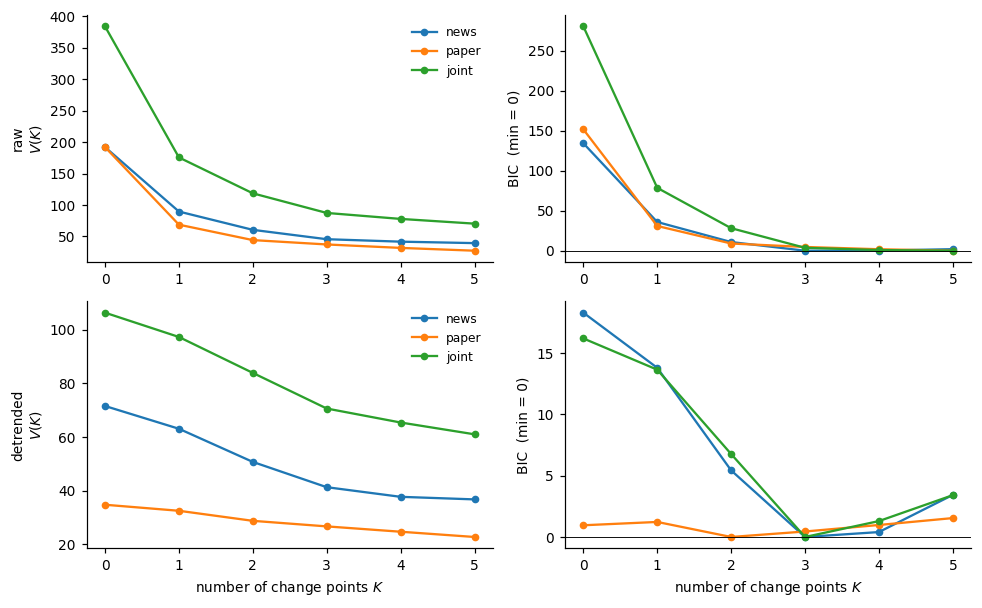

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(9, 5.6))
for r, var in enumerate(VARIANTS):
    for name in SPECS:
        tab = curves[(var, name)]
        axes[r, 0].plot(tab["K"], tab["V"], "o-", ms=4, label=name)
        axes[r, 1].plot(tab["K"], tab["BIC"] - tab["BIC"].min(), "o-", ms=4, label=name)
    axes[r, 0].set(ylabel=f"{var}\n$V(K)$")
    axes[r, 1].set(ylabel="BIC  (min = 0)")
    axes[r, 1].axhline(0, lw=.6, color="k")
    axes[r, 0].legend(frameon=False, fontsize=8)
for c in range(2):
    axes[1, c].set_xlabel("number of change points $K$")
fig.tight_layout(); plt.show()

### 6) 사양 간 일치도

정답 라벨이 없으므로, 독립적으로 얻은 두 영역의 분절이 서로 얼마나 일치하는지가
결과에 대한 주된 경험적 점검이다. margin은 최소 구간 길이(5년)보다 작아야 한다.

In [22]:
def agree(a, b, margin=2):
    A, B = list(a) + [T], list(b) + [T]
    if len(A) == 1 or len(B) == 1:
        return {"dK": abs(len(a) - len(b)), "hausdorff": np.nan,
                "rand": np.nan, "F1(±2y)": np.nan}
    p, r = precision_recall(A, B, margin=margin)
    return {"dK": abs(len(a) - len(b)), "hausdorff": hausdorff(A, B),
            "rand": round(randindex(A, B), 3),
            "F1(±2y)": round(2 * p * r / (p + r), 3) if (p + r) else 0.0}

cmp_rows = []
for var in VARIANTS:
    sub = main[main["variant"] == var].set_index("spec")
    for x, y in [("news", "paper"), ("news", "joint"), ("paper", "joint")]:
        cmp_rows.append({"variant": var, "pair": f"{x} vs {y}",
                         **agree(sub.loc[x, "idx"], sub.loc[y, "idx"])})
cmp_tab = pd.DataFrame(cmp_rows)
cmp_tab

,variant,pair,dK,hausdorff,rand,F1(±2y)
0,raw,news vs paper,2,4.0,0.814,0.0
1,raw,news vs joint,2,5.0,0.884,0.5
2,raw,paper vs joint,0,2.0,0.903,0.6
3,detrended,news vs paper,1,6.0,0.763,0.4
4,detrended,news vs joint,0,1.0,0.966,1.0
5,detrended,paper vs joint,1,6.0,0.771,0.4


### 8) 구간별 프로파일 (표준화 단위)


In [24]:
prof = []
for var in VARIANTS:
    for dom in DOMAINS:
        Y = VARIANTS[var][dom]
        ix = main[(main.variant == var) & (main.spec == dom)]["idx"].iloc[0]
        edges = [0] + list(ix) + [T]
        for p, (a, b) in enumerate(zip(edges[:-1], edges[1:]), start=1):
            prof.append({"variant": var, "domain": dom, "period": f"P{p}",
                         "years": f"{YEARS[a]}–{YEARS[b-1]}", "n": b - a,
                         **dict(zip(MEASURES, Y[a:b].mean(0).round(2)))})
prof = pd.DataFrame(prof)
prof

,variant,domain,period,years,n,C,R,S,H,D,M
0,raw,news,P1,1991–1997,7,1.21,1.74,-1.62,-1.52,-0.71,-1.24
1,raw,news,P2,1998–2008,11,0.08,-0.29,0.07,0.04,0.46,-0.51
2,raw,news,P3,2009–2016,8,-0.74,-0.26,0.25,0.12,-0.66,0.61
3,raw,news,P4,2017–2023,7,-0.49,-0.99,1.22,1.32,0.74,1.35
4,raw,paper,P1,1991–1995,5,1.36,-1.23,-1.51,-1.62,1.10,-1.45
5,raw,paper,P2,1996–2001,6,1.10,-0.81,-1.04,-0.92,-0.02,-0.87
6,raw,paper,P3,2002–2006,5,0.22,-0.03,-0.04,-0.08,0.43,-0.31
7,raw,paper,P4,2007–2012,6,-0.57,-0.01,0.51,0.53,0.28,0.25
8,raw,paper,P5,2013–2018,6,-0.93,0.51,0.77,0.93,-0.91,0.85
9,raw,paper,P6,2019–2023,5,-1.11,1.64,1.26,1.05,-0.74,1.49


### 9) 강건성

1. **최소 구간 길이** 4–7년
2. **비용함수** — 주 분석의 K를 고정하고 커널·순위 비용으로 교체
   (비용 스케일이 달라 벌점이 호환되지 않으므로 K는 고정)

In [25]:
rob_ms = []
for ms in [4, 5, 6, 7]:
    for var, specs in VARIANTS.items():
        for name, Y in specs.items():
            tab, K_hat, _ = fit_spec(Y, min_size=ms)
            rob_ms.append({"variant": var, "spec": name, "min_size": ms,
                           "K": K_hat,
                           "boundaries": to_years(tab.loc[tab.K == K_hat,
                                                          "bkps"].iloc[0])})
rob_ms = pd.DataFrame(rob_ms)
rob_ms.pivot(index=["variant", "spec"], columns="min_size", values="boundaries")

min_size                                      4  \
variant   spec                                    
detrended joint        [1998, 2002, 2010, 2017]   
          news         [1998, 2002, 2010, 2017]   
          paper              [2009, 2013, 2019]   
raw       joint  [1998, 2002, 2009, 2013, 2019]   
          news   [1998, 2002, 2009, 2016, 2020]   
          paper  [1995, 2002, 2009, 2013, 2019]   

min_size                                      5                         6  \
variant   spec                                                              
detrended joint              [1998, 2009, 2017]        [1998, 2009, 2017]   
          news               [1998, 2010, 2017]        [1998, 2010, 2017]   
          paper                    [2003, 2016]              [2003, 2016]   
raw       joint  [1998, 2003, 2009, 2014, 2019]  [1998, 2004, 2010, 2017]   
          news               [1998, 2009, 2017]        [1998, 2009, 2017]   
          paper  [1996, 2002, 2007, 2013, 2019]  [1997, 2003, 2009, 2015]   

min_size                          7  
variant   spec                       
detrended joint  [1998, 2009, 2017]  
          news   [1998, 2010, 2017]  
          paper        [2003, 2016]  
raw       joint  [1998, 2006, 2017]  
          news   [1998, 2009, 2017]  
          paper  [1998, 2005, 2015]

In [26]:
rob_cost = []
for var, specs in VARIANTS.items():
    for name, Y in specs.items():
        K_hat = int(main[(main.variant == var) & (main.spec == name)]["K"].iloc[0])
        row = {"variant": var, "spec": name, "K": K_hat}
        for model in COSTS:
            if K_hat == 0:
                row[model] = []
                continue
            cost = COSTS[model]().fit(Y)
            b = rpt.Dynp(custom_cost=cost, min_size=MIN_SIZE,
                         jump=1).fit(Y).predict(n_bkps=K_hat)
            row[model] = to_years(b[:-1])
        rob_cost.append(row)
rob_cost = pd.DataFrame(rob_cost)
rob_cost

,variant,spec,K,l2,rbf,rank
0,raw,news,3,"[1998, 2009, 2017]","[1998, 2009, 2017]","[1998, 2006, 2013]"
1,raw,paper,5,"[1996, 2002, 2007, 2013, 2019]","[1996, 2002, 2007, 2013, 2019]","[1996, 2002, 2007, 2012, 2017]"
2,raw,joint,5,"[1998, 2003, 2009, 2014, 2019]","[1998, 2004, 2009, 2014, 2019]","[1998, 2004, 2009, 2014, 2019]"
3,detrended,news,3,"[1998, 2010, 2017]","[2000, 2010, 2017]","[1998, 2010, 2018]"
4,detrended,paper,2,"[2003, 2016]","[2003, 2016]","[2002, 2016]"
5,detrended,joint,3,"[1998, 2009, 2017]","[1998, 2010, 2017]","[1998, 2003, 2016]"


### 10) 부트스트랩 — 경계 위치의 안정성

구간 내 잔차를 순환 블록(길이 4년)으로 재표집해 계열을 재구성하고, 매 복제마다
K 선택부터 다시 수행한다. 경계 연도가 얼마나 자주 재현되는지를 센다.

In [27]:
B_REP, BLOCK = 500, 4
rng = np.random.default_rng(20260821)

def circ_block_resample(res, rng, block=BLOCK):
    n = len(res); out = []
    while len(out) < n:
        s = rng.integers(0, n)
        out.extend(((s + np.arange(block)) % n).tolist())
    return res[np.array(out[:n])]

boot = {}
for var, specs in VARIANTS.items():
    for name, Y in specs.items():
        ix = main[(main.variant == var) & (main.spec == name)]["idx"].iloc[0]
        edges = [0] + list(ix) + [T]
        fit = np.vstack([np.repeat(Y[a:b].mean(0)[None, :], b - a, axis=0)
                         for a, b in zip(edges[:-1], edges[1:])])
        res = Y - fit
        hits, Ks = {}, []
        for _ in range(B_REP):
            Yb = fit + circ_block_resample(res, rng)
            tab, K_hat, _ = fit_spec(Yb)
            Ks.append(K_hat)
            for y in to_years(tab.loc[tab.K == K_hat, "bkps"].iloc[0]):
                hits[y] = hits.get(y, 0) + 1
        boot[(var, name)] = {"K_mode": int(pd.Series(Ks).mode()[0]),
                             "K_dist": pd.Series(Ks).value_counts(normalize=True)
                                          .round(3).to_dict(),
                             "top_boundaries": sorted(hits.items(),
                                                      key=lambda kv: -kv[1])[:5]}

boot_tab = pd.DataFrame([
    {"variant": v, "spec": s, "K̂": int(main[(main.variant == v) &
                                            (main.spec == s)]["K"].iloc[0]),
     "K_mode(boot)": d["K_mode"], "K_dist": d["K_dist"],
     "boundary : freq": {y: round(c / B_REP, 2) for y, c in d["top_boundaries"]}}
    for (v, s), d in boot.items()])
boot_tab

,variant,spec,K̂,K_mode(boot),K_dist,boundary : freq
0,raw,news,3,3,"{3: 0.944, 4: 0.042, 2: 0.014}","{1998: 1.0, 2017: 0.99, 2009: 0.76, 2010: 0.07..."
1,raw,paper,5,5,"{5: 0.61, 4: 0.328, 3: 0.05, 2: 0.012}","{2002: 0.99, 1996: 0.85, 2019: 0.84, 2013: 0.7..."
2,raw,joint,5,4,"{4: 0.51, 5: 0.384, 3: 0.106}","{1998: 1.0, 2019: 0.87, 2003: 0.78, 2014: 0.73..."
3,detrended,news,3,3,"{3: 0.85, 4: 0.092, 2: 0.058}","{1998: 0.92, 2010: 0.88, 2017: 0.66, 2018: 0.1..."
4,detrended,paper,2,2,"{2: 0.616, 0: 0.196, 3: 0.114, 1: 0.066, 4: 0....","{2016: 0.45, 2003: 0.31, 2004: 0.09, 2002: 0.0..."
5,detrended,joint,3,3,"{3: 0.908, 2: 0.054, 4: 0.03, 0: 0.008}","{1998: 0.93, 2009: 0.86, 2017: 0.71, 2018: 0.0..."


### 11) 저장


In [28]:
main.drop(columns="idx").to_csv(OUT / "periodization_main.csv", index=False)
cmp_tab.to_csv(OUT / "periodization_agreement.csv", index=False)
prof.to_csv(OUT / "periodization_profiles.csv", index=False)
corr.to_csv(OUT / "measure_year_correlation.csv")
rob_ms.to_csv(OUT / "robustness_min_size.csv", index=False)
rob_cost.to_csv(OUT / "robustness_cost.csv", index=False)
boot_tab.astype(str).to_csv(OUT / "bootstrap_stability.csv", index=False)
pd.concat([t.assign(variant=v, spec=s) for (v, s), t in curves.items()]) \
  .drop(columns="bkps").to_csv(OUT / "model_selection_curves.csv", index=False)
print(*sorted(p.name for p in OUT.glob("*.csv")), sep="\n")

bootstrap_stability.csv
measure_year_correlation.csv
model_selection_curves.csv
periodization_agreement.csv
periodization_main.csv
periodization_profiles.csv
robustness_cost.csv
robustness_min_size.csv
